# NOTEBOOK: Data Exploration & Model Selection

 Purpose:
 - Explore datasets to understand structure, distributions, relationships
 - Identify data quality issues (missing values, outliers)
 - Analyze feature-target correlations
 - Get model recommendations based on data characteristics

This analysis is done ONCE per dataset, then referenced in model-specific notebooks.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    detect_task_type,
    print_task_detection_report,
    plot_feature_distributions_by_class,
    analyze_class_separability,
    analyze_data,
    plot_distributions,
    plot_feature_target_relationships,
    analyze_feature_importance_for_model_selection,
    correlation_heatmap,
    detect_outliers_iqr,
    plot_feature_pairwise,
    analyze_clustering_suitability,
)

# Set style
plt.style.use('default')
sns.set_palette("husl")

## Load Dataset

In [3]:
DATASET = 'customer_segmentation'  # Change this to explore different datasets

if DATASET == 'california_housing':
    X, y = data_loader.load_california_housing()
    dataset_name = "California Housing"
    target_name = "Median House Value ($100k)"
    
elif DATASET == 'insurance':
    X, y = data_loader.load_insurance()
    dataset_name = "Medical Insurance"
    target_name = "Insurance Charges ($)"

elif DATASET == 'ames_housing':
    X, y = data_loader.load_ames_housing()
    dataset_name = "Ames Housing"
    target_name = "Sale Price ($)"

elif DATASET == 'iris':
    X, y = data_loader.load_iris()
    dataset_name = "Iris Flowers"
    target_name = "Species"

elif DATASET == 'breast_cancer':
    X, y = data_loader.load_breast_cancer()
    dataset_name = "Breast Cancer"
    target_name = "Malignant"

elif DATASET == 'titanic':
    X, y = data_loader.load_titanic()
    dataset_name = "Titanic"
    target_name = "Survived"

elif DATASET == 'clustering_blobs':
    X, y_true = data_loader.load_clustering_blobs()
    y = None  # ← No target!
    dataset_name = "Clustering Blobs"
    task_type = 'clustering'  # ← Explicitly set

elif DATASET == 'customer_segmentation':
    X = data_loader.load_customer_segmentation()
    y = None  # ← No target!
    dataset_name = "Customer Segmentation"
    task_type = 'clustering'  # ← Explicitly set
    
# Add more datasets as needed

print(f"Dataset: {dataset_name}")
print(f"Shape: {X.shape[0]} samples, {X.shape[1]} features")

# Auto-detect task type (only if not clustering)
if task_type != 'clustering':
  task_info = detect_task_type(y)
  print_task_detection_report(task_info)
  task_type = task_info['task_type']
else:
    # Clustering - no detection needed
    print("\n" + "="*70)
    print("CLUSTERING (UNSUPERVISED LEARNING)")
    print("="*70)
    print("\n💡 Task Type: CLUSTERING")
    print("   - No target variable (unsupervised learning)")
    print("   - Goal: Find natural groupings in the data")
    print("="*70)

Dataset: Customer Segmentation
Shape: 200 samples, 3 features

CLUSTERING (UNSUPERVISED LEARNING)

💡 Task Type: CLUSTERING
   - No target variable (unsupervised learning)
   - Goal: Find natural groupings in the data


## Basic Data Analysis

In [4]:
analysis = analyze_data(X, show_stats=True)

DATA ANALYSIS

Dataset shape: 200 rows × 3 columns

Data types:
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

✓ No missing values found

Numerical columns (3):
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Categorical columns (0):
[]

Numerical features statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


## Feature Distributions

Feature Distributions (Marginal)
----------------------------------------------------------------------
Look for:
  - Normal/Gaussian shape → Good for linear models
  - Skewed distributions → Consider log transform
  - Outliers (long tails) → Decide to keep/remove/transform



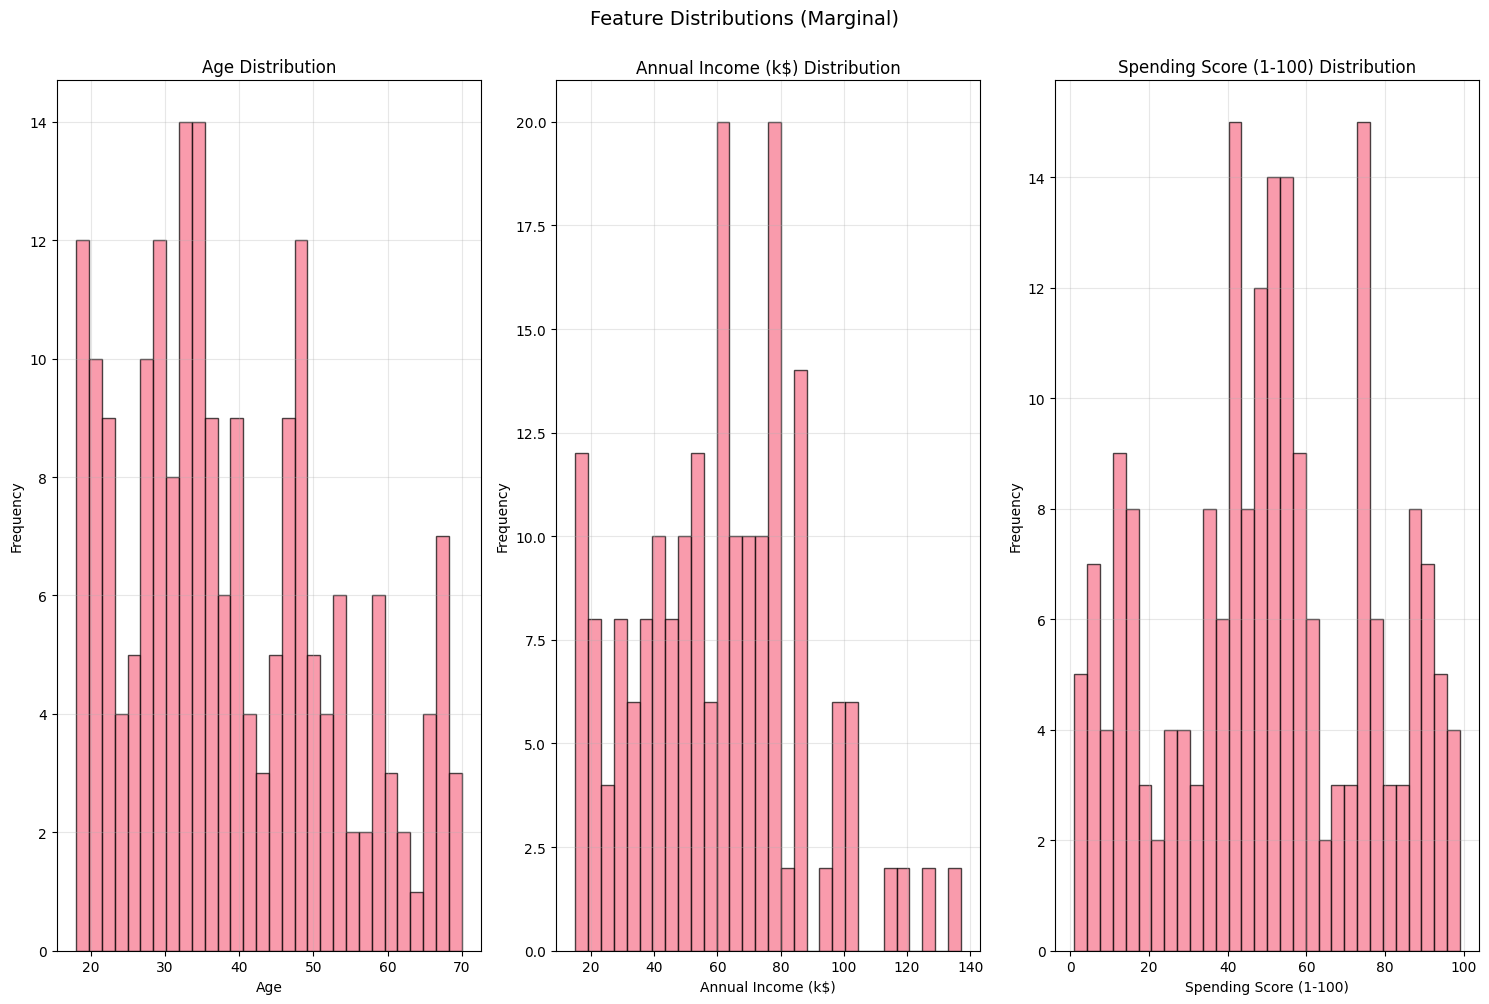

In [5]:
print("Feature Distributions (Marginal)")
print("-" * 70)
print("Look for:")
print("  - Normal/Gaussian shape → Good for linear models")
print("  - Skewed distributions → Consider log transform")
print("  - Outliers (long tails) → Decide to keep/remove/transform")
print()

plot_distributions(X)

## Outlier Detection

In [6]:
print("\n" + "="*70)
print("OUTLIER ANALYSIS")
print("="*70)
print("Purpose: Identify extreme values")
print("Decision:")
print("  - < 5% outliers & legitimate → KEEP (use StandardScaler)")
print("  - > 10% outliers → Investigate data quality")
print("  - Data errors → REMOVE before training")
print()

outliers = detect_outliers_iqr(X, threshold=1.5)

if outliers:
    print("\nOutlier Summary:")
    for col, mask in outliers.items():
        pct = mask.sum() / len(X) * 100
        print(f"  {col}: {mask.sum()} outliers ({pct:.1f}%)")
    
    print("\n💡 Recommendation:")
    max_outlier_pct = max(mask.sum() / len(X) * 100 for mask in outliers.values())
    if max_outlier_pct < 5:
        print("  ✅ Few outliers - keep them, use StandardScaler")
    elif max_outlier_pct < 10:
        print("  ⚠️  Moderate outliers - investigate, likely keep with StandardScaler")
    else:
        print("  ❌ Many outliers - investigate data quality issues")


OUTLIER ANALYSIS
Purpose: Identify extreme values
Decision:
  - < 5% outliers & legitimate → KEEP (use StandardScaler)
  - > 10% outliers → Investigate data quality
  - Data errors → REMOVE before training


OUTLIER DETECTION (IQR Method)
Annual Income (k$)  :    2 outliers (  1.0%) [< -13.25 or > 132.75]

Outlier Summary:
  Annual Income (k$): 2 outliers (1.0%)

💡 Recommendation:
  ✅ Few outliers - keep them, use StandardScaler


## Feature-Target Analysis


PAIRWISE FEATURE RELATIONSHIPS (Clustering)
Look for:
  - Natural groupings or clusters
  - Clear separation between groups
  - Dense regions vs sparse regions



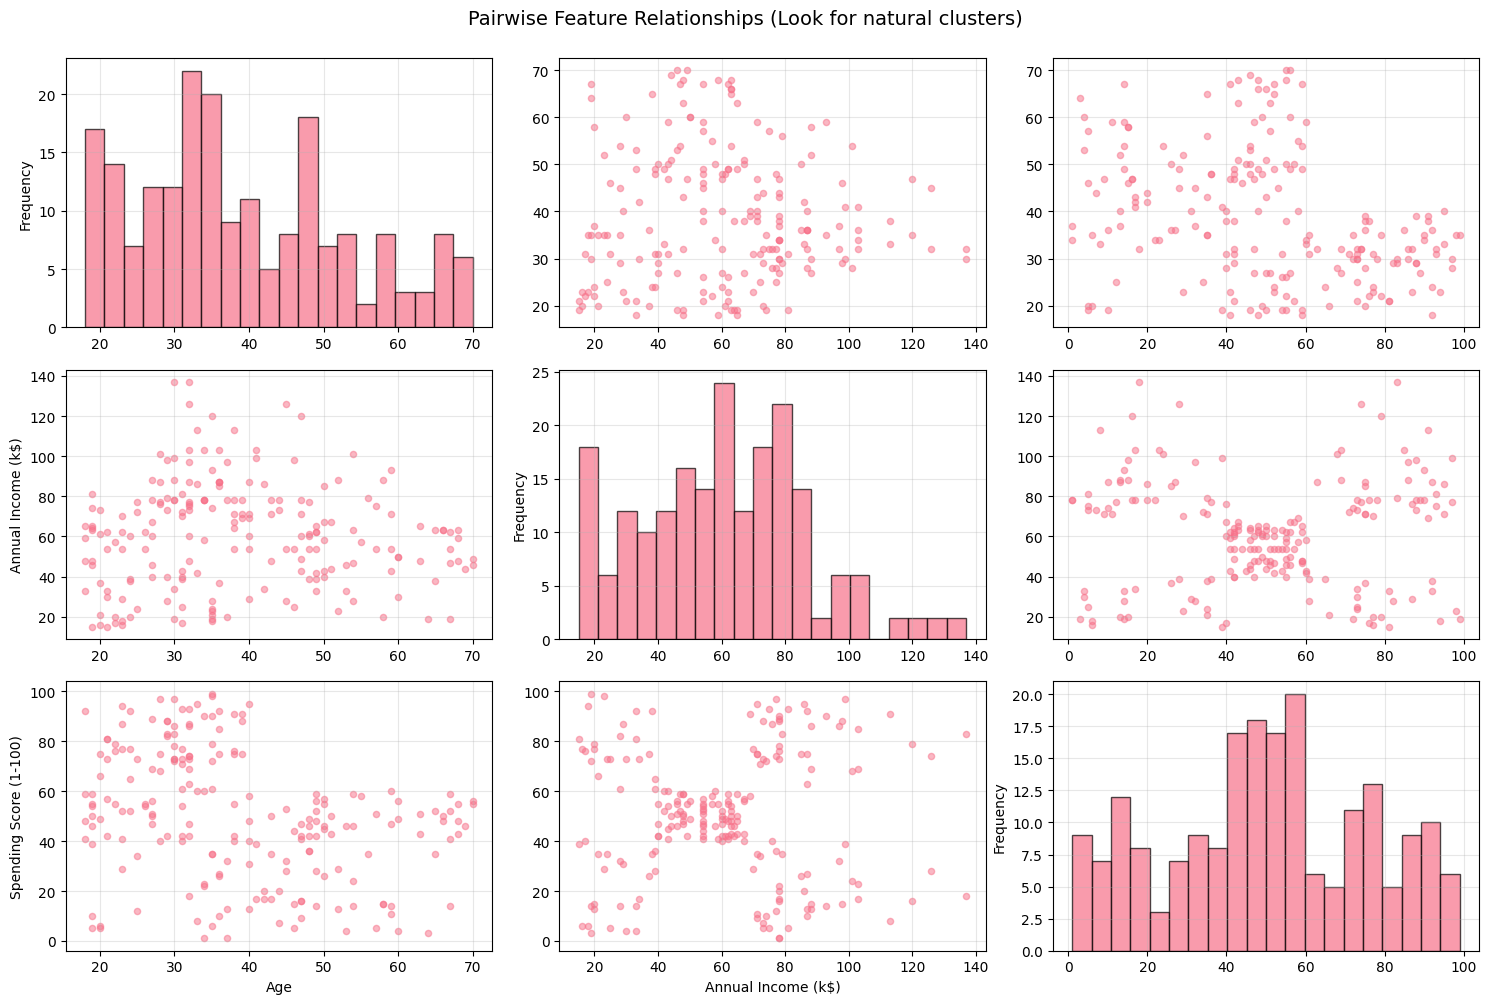

In [7]:
if task_type == "regression":
    # === REGRESSION ANALYSIS ===
    print("\n" + "="*70)
    print("FEATURE-TARGET RELATIONSHIPS (Regression)")
    print("="*70)
    print("Look for:")
    print("  - Linear patterns (straight line) → Linear Regression will work")
    print("  - Curved patterns → Need polynomial features or tree-based models")
    print("  - No pattern (random scatter) → Feature not useful")
    print()
    
    plot_feature_target_relationships(X, y)
    
elif task_type == "classification":
    # === CLASSIFICATION ANALYSIS ===
    print("\n" + "="*70)
    print("FEATURE DISTRIBUTIONS BY CLASS (Classification)")
    print("="*70)
    print("Look for:")
    print("  - Clear separation between classes → Feature is discriminative")
    print("  - Overlapping distributions → Feature less useful")
    print("  - One class clearly separated → Feature perfect for that class")
    print()
    
    # Don't use class_names at all - functions work without it
    plot_feature_distributions_by_class(X, y)
    
elif task_type == "clustering":
    # === CLUSTERING ANALYSIS ===
    print("\n" + "="*70)
    print("PAIRWISE FEATURE RELATIONSHIPS (Clustering)")
    print("="*70)
    print("Look for:")
    print("  - Natural groupings or clusters")
    print("  - Clear separation between groups")
    print("  - Dense regions vs sparse regions")
    print()
    
    from src.eda import plot_feature_pairwise
    plot_feature_pairwise(X, sample_size=1000)

## Model Recommendations

In [8]:
recommendations = {}

if task_type == "regression":
    # === REGRESSION: Correlation Heatmap ===
    print("\n" + "="*70)
    print("CORRELATION ANALYSIS")
    print("="*70)
    print("Look for:")
    print("  - High correlation with target (dark red/blue) → Important features")
    print("  - High correlation between features (> 0.9) → Multicollinearity")
    print()
    
    correlation_heatmap(X, y)

    # Get recommendations
    recommendations = analyze_feature_importance_for_model_selection(X, y)
    
elif task_type == "classification":
    # === CLASSIFICATION: Class Separability ===
    # Don't pass class_names - function will use generic labels
    recommendations = analyze_class_separability(X, y)

elif task_type == "clustering":
    # === CLUSTERING SUITABILITY ===
    from src.eda import analyze_clustering_suitability
    recommendations = analyze_clustering_suitability(X)

CLUSTERING SUITABILITY ANALYSIS

Feature Variance Analysis:
----------------------------------------------------------------------
Age                 :   195.1332 (High)
Annual Income (k$)  :   689.8356 (High)
Spending Score (1-100):   666.8543 (High)

FEATURE CORRELATION ANALYSIS

✓ No highly correlated features (> 0.9)

DATASET SIZE ANALYSIS

Samples: 200
Features: 3
Samples per feature: 66.7
✓ Sufficient samples for clustering

CLUSTERING METHOD RECOMMENDATIONS

Recommended Methods:
  • K-Means
  • DBSCAN
  • Hierarchical Clustering
  • Gaussian Mixture Models

Reasoning:
  ✅ K-Means: Fast, works well for spherical clusters
  ✅ DBSCAN: Finds arbitrary-shaped clusters, handles outliers
  ✅ Hierarchical: Creates dendrogram, no need to specify k
  ✅ GMM: Soft clustering, handles overlapping clusters

IMPORTANT NOTES:
• Always scale features before clustering (StandardScaler)
• Try multiple values of k (K-Means) or eps/min_samples (DBSCAN)
• Use elbow method or silhouette score to choo

## Summary & Next Steps

In [9]:
print("\n" + "="*70)
print(f"SUMMARY: {dataset_name}")
print("="*70)

print(f"\n📊 Dataset Characteristics:")
print(f"  - Task Type: {task_type.upper()}")
print(f"  - Samples: {X.shape[0]}")
print(f"  - Features: {X.shape[1]}")
print(f"  - Numerical: {len(analysis['numerical_cols'])}")
print(f"  - Categorical: {len(analysis['categorical_cols'])}")
print(f"  - Missing values: {analysis['missing_summary'].sum()[0] if len(analysis['missing_summary']) > 0 else 0}")

# Task-specific info
if task_type == "classification":
    n_classes = recommendations.get('n_classes', len(np.unique(y)))
    print(f"  - Number of classes: {n_classes}")
    unique_vals = sorted(np.unique(y))
    print(f"  - Class values: {unique_vals}")
    
elif task_type == "clustering":
    print(f"  - Target variable: None (unsupervised)")
    low_var = recommendations.get('low_variance_features', 0)
    if low_var > 0:
        print(f"  - Low variance features: {low_var} (consider removing)")

# Outliers
if outliers:
    print(f"\n⚠️  Outliers Detected:")
    for col, mask in list(outliers.items())[:3]:
        pct = mask.sum() / len(X) * 100
        print(f"  - {col}: {pct:.1f}%")

# Recommended models/methods
recommended_models = recommendations.get('recommended_models', [])
if recommended_models:
    print(f"\n🎯 Recommended {'Methods' if task_type == 'clustering' else 'Models'}:")
    for model in recommended_models:
        print(f"  ✓ {model}")

# Key Insights
print(f"\n📝 Key Insights:")

if task_type == "regression":
    strong = recommendations.get('strong_linear_features', 0)
    moderate = recommendations.get('moderate_linear_features', 0)
    weak = recommendations.get('weak_linear_features', 0)
    
    print(f"  - Strong linear relationships: {strong} features")
    print(f"  - Moderate linear relationships: {moderate} features")
    print(f"  - Weak linear relationships: {weak} features")
    
    if strong >= 3:
        print(f"  💡 Linear models should perform well")
    elif weak > strong:
        print(f"  💡 Consider non-linear models (trees, neural networks)")
    
elif task_type == "classification":
    strong_features = recommendations.get('strong_features', 0)
    n_features = recommendations.get('n_features', len(analysis['numerical_cols']))
    n_classes = recommendations.get('n_classes', len(np.unique(y)))
    
    print(f"  - Highly discriminative features: {strong_features} features")
    print(f"  - Total features: {n_features}")
    print(f"  - Classes to predict: {n_classes}")
    
    if strong_features >= n_features * 0.7:
        print(f"  💡 Features show excellent class separation")
    elif strong_features >= n_features * 0.4:
        print(f"  💡 Features show good class separation")
    else:
        print(f"  💡 Features show moderate class separation")
    
    class_balance = recommendations.get('class_balance', 1)
    if class_balance > 3:
        print(f"  ⚠️  Classes are imbalanced ({class_balance:.1f}:1 ratio)")
    else:
        print(f"  ✓ Classes are balanced")
        
elif task_type == "clustering":
    n_samples = recommendations.get('n_samples', len(X))
    n_features = recommendations.get('n_features', len(analysis['numerical_cols']))
    low_var = recommendations.get('low_variance_features', 0)
    high_corr = recommendations.get('high_corr_pairs', 0)
    
    print(f"  - Samples: {n_samples}")
    print(f"  - Features: {n_features}")
    
    if low_var > 0:
        print(f"  ⚠️  {low_var} low variance features (consider removing)")
    else:
        print(f"  ✓ All features have good variance")
    
    if high_corr > 0:
        print(f"  ⚠️  {high_corr} highly correlated feature pairs (consider reducing)")
    else:
        print(f"  ✓ Features are not highly correlated")
    
    if n_samples / n_features > 10:
        print(f"  💡 Good ratio of samples to features")
    else:
        print(f"  ⚠️  Low sample-to-feature ratio - results may be unreliable")

# Next Steps
print(f"\n📁 Next Steps:")

if task_type == "regression":
    print(f"  1. Preprocess data:")
    print(f"     - Scale features (StandardScaler)")
    print(f"     - Encode categorical features")
    print(f"     - Handle missing values")
    if outliers:
        print(f"     - Decide on outlier strategy")
    
    print(f"  2. Try recommended regression models")
    print(f"  3. Evaluate with R², RMSE, cross-validation")
    print(f"\n  📂 Navigate to: notebooks/01_supervised_learning/regression/")

elif task_type == "classification":
    print(f"  1. Preprocess data:")
    print(f"     - Scale features (for distance-based models)")
    print(f"     - Encode categorical features")
    print(f"     - Handle missing values")
    
    class_balance = recommendations.get('class_balance', 1)
    if class_balance > 3:
        print(f"     - Address class imbalance")
    
    print(f"  2. Try recommended classification models")
    print(f"  3. Evaluate with accuracy, confusion matrix, F1-score")
    print(f"\n  📂 Navigate to: notebooks/01_supervised_learning/classification/")

elif task_type == "clustering":
    print(f"  1. Preprocess data:")
    print(f"     - ALWAYS scale features (StandardScaler) - critical for clustering!")
    print(f"     - Encode categorical features (if any)")
    print(f"     - Handle missing values")
    if low_var > 0:
        print(f"     - Remove low variance features")
    if high_corr > 0:
        print(f"     - Remove highly correlated features")
    
    print(f"  2. Try recommended clustering methods:")
    for i, model in enumerate(recommended_models[:3], 1):
        print(f"     {i}. {model}")
    
    print(f"  3. Determine optimal number of clusters:")
    print(f"     - Elbow method (K-Means)")
    print(f"     - Silhouette score")
    print(f"     - Dendrogram (Hierarchical)")
    
    print(f"  4. Evaluate clustering quality:")
    print(f"     - Silhouette score")
    print(f"     - Davies-Bouldin index")
    print(f"     - Visual inspection (PCA/t-SNE)")
    
    print(f"\n  📂 Navigate to: notebooks/03_unsupervised_learning/")

print("\n" + "="*70)


SUMMARY: Customer Segmentation

📊 Dataset Characteristics:
  - Task Type: CLUSTERING
  - Samples: 200
  - Features: 3
  - Numerical: 3
  - Categorical: 0
  - Missing values: 0
  - Target variable: None (unsupervised)

⚠️  Outliers Detected:
  - Annual Income (k$): 1.0%

🎯 Recommended Methods:
  ✓ K-Means
  ✓ DBSCAN
  ✓ Hierarchical Clustering
  ✓ Gaussian Mixture Models

📝 Key Insights:
  - Samples: 200
  - Features: 3
  ✓ All features have good variance
  ✓ Features are not highly correlated
  💡 Good ratio of samples to features

📁 Next Steps:
  1. Preprocess data:
     - ALWAYS scale features (StandardScaler) - critical for clustering!
     - Encode categorical features (if any)
     - Handle missing values
  2. Try recommended clustering methods:
     1. K-Means
     2. DBSCAN
     3. Hierarchical Clustering
  3. Determine optimal number of clusters:
     - Elbow method (K-Means)
     - Silhouette score
     - Dendrogram (Hierarchical)
  4. Evaluate clustering quality:
     - Silho